Compare different model types

Note: MHC-I: (1) MHC, (2) peptide, (3) TCRA, (4) TCRB --> MHC-I: (0) MHC, (1) peptide, (2) TCRA, (3) TCRB

In [1]:
import pandas as pd
import numpy as np

In [2]:
def model_benchmarking(df, features, label_col="positive"):
    import numpy as np
    from sklearn.model_selection import cross_validate, StratifiedKFold
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler

    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
    from sklearn.metrics import make_scorer, confusion_matrix

    # --- Extract X and y ---
    X = df[features].copy()
    y = df[label_col].astype(int).copy()

    # --- Define FPR and FNR scorers ---
    def fpr(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return fp / (fp + tn) if (fp + tn) > 0 else 0.0

    def fnr(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return fn / (fn + tp) if (fn + tp) > 0 else 0.0

    class_weight = {0: 1.0, 1: 10.0}

    # --- base estimators ---
    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, class_weight=class_weight),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1, class_weight=class_weight, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(random_state=1),
        "AdaBoost": AdaBoostClassifier(random_state=1),
        "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1, class_weight=class_weight, n_jobs=-1),
        "SVM": SVC(random_state=1, probability=False, class_weight=class_weight),
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=1, class_weight=class_weight),
        "Naive Bayes": GaussianNB(),
        "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
        "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
    }

    # --- wrap with preprocessing (inside-CV, no leakage) ---
    # scale only where it matters (distance/linear models)
    scale_names = {
        "Logistic Regression",
        "SVM",
        "K-Nearest Neighbors",
        "Linear Discriminant Analysis",
        "Quadratic Discriminant Analysis",
    }

    def wrap_model(name, estimator):
        steps = [("imputer", SimpleImputer(strategy="median"))]
        if name in scale_names:
            steps.append(("scaler", StandardScaler()))
        steps.append(("model", estimator))
        return Pipeline(steps)

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "fpr": make_scorer(fpr),
        "fnr": make_scorer(fnr),
        "balanced_acc": "balanced_accuracy",
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    results = {}
    for name, estimator in models.items():
        pipe = wrap_model(name, estimator)
        cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

        results[name] = {metric: cv_results[f"test_{metric}"].mean() for metric in scoring.keys()}

        print(
            f"{name}: "
            f"Acc={results[name]['accuracy']:.3f}, "
            f"Prec={results[name]['precision']:.3f}, "
            f"Rec={results[name]['recall']:.3f}, "
            f"F1={results[name]['f1']:.3f}, "
            f"FPR={results[name]['fpr']:.3f}, "
            f"FNR={results[name]['fnr']:.3f}, "
            f"BalAcc={results[name]['balanced_acc']:.3f}"
        )

    results_df = pd.DataFrame(results).T
    print("\n" + "=" * 80)
    print(results_df)
    print("=" * 80)
    return results_df

In [3]:
df = pd.read_csv("dt/combined_BEAM_with_inSilicoNegatives.csv")

/tmp/ipykernel_2781702/3035507597.py:1: DtypeWarning: Columns (69,75,83,85,86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dt/combined_BEAM_with_inSilicoNegatives.csv")


In [4]:
df['positive'].value_counts()

positive
False    9020
True     1972
Name: count, dtype: int64

In [5]:
# df = df[(df['type'] == "negative_binder") | (df['type'] == "binder")]

In [6]:
# df = pd.concat([df, df[df['positive']]], ignore_index=True)
# df = pd.concat([df, df[df['positive']]], ignore_index=True)
df['positive'].value_counts()

positive
False    9020
True     1972
Name: count, dtype: int64

In [7]:
df = df.sample(frac=1, random_state=1)

In [8]:
features = ["pmhc_tcr_pae", "model_2_ptm_ft4_plddt"]
res_af_simple = model_benchmarking(df, features, label_col="positive")

Logistic Regression: Acc=0.180, Prec=0.179, Rec=0.998, F1=0.304, FPR=0.999, FNR=0.002, BalAcc=0.500
Random Forest: Acc=0.836, Prec=0.598, Rec=0.262, F1=0.364, FPR=0.039, FNR=0.738, BalAcc=0.612
Gradient Boosting: Acc=0.835, Prec=0.772, Rec=0.112, F1=0.196, FPR=0.007, FNR=0.888, BalAcc=0.552
AdaBoost: Acc=0.834, Prec=0.819, Rec=0.093, F1=0.167, FPR=0.005, FNR=0.907, BalAcc=0.544
Extra Trees: Acc=0.825, Prec=0.522, Rec=0.274, F1=0.360, FPR=0.055, FNR=0.726, BalAcc=0.610
SVM: Acc=0.191, Prec=0.180, Rec=0.990, F1=0.305, FPR=0.984, FNR=0.010, BalAcc=0.503
K-Nearest Neighbors: Acc=0.813, Prec=0.452, Rec=0.198, F1=0.276, FPR=0.052, FNR=0.802, BalAcc=0.573
Decision Tree: Acc=0.774, Prec=0.365, Rec=0.352, F1=0.358, FPR=0.134, FNR=0.648, BalAcc=0.609
Naive Bayes: Acc=0.819, Prec=0.478, Rec=0.114, F1=0.183, FPR=0.027, FNR=0.886, BalAcc=0.543
Linear Discriminant Analysis: Acc=0.821, Prec=0.600, Rec=0.003, F1=0.005, FPR=0.000, FNR=0.997, BalAcc=0.501
Quadratic Discriminant Analysis: Acc=0.813, Prec

/rfs/project/rfs-iCNyzSAaucw/yzy21/micromamba/envs/stcrpy/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [10]:
res_af_simple.sort_values("balanced_acc",ascending = False)

,accuracy,precision,recall,f1,fpr,fnr,balanced_acc
Random Forest,0.835791,0.597702,0.262186,0.364354,0.038803,0.737814,0.611692
Extra Trees,0.824510,0.522189,0.274360,0.359596,0.055211,0.725640,0.609575
Decision Tree,0.773653,0.364726,0.351928,0.358178,0.134146,0.648072,0.608891
K-Nearest Neighbors,0.813137,0.452220,0.198273,0.275624,0.052439,0.801727,0.572917
Gradient Boosting,0.834607,0.772169,0.112070,0.195616,0.007428,0.887930,0.552321
AdaBoost,0.833516,0.819389,0.092797,0.166501,0.004545,0.907203,0.544126
Naive Bayes,0.818504,0.477592,0.113599,0.183144,0.027384,0.886401,0.543108
Quadratic Discriminant Analysis,0.812864,0.380511,0.068464,0.115984,0.024390,0.931536,0.522037
SVM,0.191048,0.180414,0.990363,0.305219,0.983703,0.009637,0.503330
Linear Discriminant Analysis,0.820870,0.600000,0.002536,0.005048,0.000222,0.997464,0.501157


In [19]:
features = ["pmhc_tcr_pae", "model_2_ptm_ft4_plddt",'model_2_ptm_ft4_pae', 'model_2_ptm_ft4_plddt_0',
       'model_2_ptm_ft4_pae_0_0', 'model_2_ptm_ft4_pae_0_1',
       'model_2_ptm_ft4_pae_0_2', 'model_2_ptm_ft4_pae_0_3',
       'model_2_ptm_ft4_plddt_1', 'model_2_ptm_ft4_pae_1_0',
       'model_2_ptm_ft4_pae_1_1', 'model_2_ptm_ft4_pae_1_2',
       'model_2_ptm_ft4_pae_1_3', 'model_2_ptm_ft4_plddt_2',
       'model_2_ptm_ft4_pae_2_0', 'model_2_ptm_ft4_pae_2_1',
       'model_2_ptm_ft4_pae_2_2', 'model_2_ptm_ft4_pae_2_3',
       'model_2_ptm_ft4_plddt_3', 'model_2_ptm_ft4_pae_3_0',
       'model_2_ptm_ft4_pae_3_1', 'model_2_ptm_ft4_pae_3_2',
       'model_2_ptm_ft4_pae_3_3',]
res_af2_v2 = model_benchmarking(df, features, label_col="positive")

Logistic Regression: Acc=0.494, Prec=0.247, Rec=0.890, F1=0.387, FPR=0.593, FNR=0.110, BalAcc=0.649
Random Forest: Acc=0.899, Prec=0.858, Rec=0.526, F1=0.652, FPR=0.019, FNR=0.474, BalAcc=0.754
Gradient Boosting: Acc=0.881, Prec=0.827, Rec=0.430, F1=0.565, FPR=0.020, FNR=0.570, BalAcc=0.705
AdaBoost: Acc=0.860, Prec=0.791, Rec=0.300, F1=0.434, FPR=0.018, FNR=0.700, BalAcc=0.641
Extra Trees: Acc=0.899, Prec=0.864, Rec=0.522, F1=0.650, FPR=0.018, FNR=0.478, BalAcc=0.752
SVM: Acc=0.619, Prec=0.307, Rec=0.898, F1=0.458, FPR=0.442, FNR=0.102, BalAcc=0.728
K-Nearest Neighbors: Acc=0.877, Prec=0.734, Rec=0.488, F1=0.586, FPR=0.039, FNR=0.512, BalAcc=0.725
Decision Tree: Acc=0.849, Prec=0.580, Rec=0.585, F1=0.582, FPR=0.093, FNR=0.415, BalAcc=0.746
Naive Bayes: Acc=0.787, Prec=0.406, Rec=0.405, F1=0.405, FPR=0.130, FNR=0.595, BalAcc=0.638
Linear Discriminant Analysis: Acc=0.859, Prec=0.723, Rec=0.346, F1=0.468, FPR=0.029, FNR=0.654, BalAcc=0.659
Quadratic Discriminant Analysis: Acc=0.868, Prec

/rfs/project/rfs-iCNyzSAaucw/yzy21/micromamba/envs/stcrpy/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/rfs/project/rfs-iCNyzSAaucw/yzy21/micromamba/envs/stcrpy/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/rfs/project/rfs-iCNyzSAaucw/yzy21/micromamba/envs/stcrpy/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/rfs/project/rfs-iCNyzSAaucw/yzy21/micromamba/envs/stcrpy/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1

In [20]:
res_af2_v2.sort_values("balanced_acc",ascending = False)

,accuracy,precision,recall,f1,fpr,fnr,balanced_acc
Random Forest,0.899290,0.857502,0.526365,0.651696,0.019180,0.473635,0.753593
Extra Trees,0.899381,0.863809,0.521804,0.650192,0.018071,0.478196,0.751867
Quadratic Discriminant Analysis,0.867993,0.652280,0.566920,0.606318,0.066186,0.433080,0.750367
Decision Tree,0.849345,0.579998,0.584688,0.581911,0.092794,0.415312,0.745947
SVM,0.618996,0.307500,0.897588,0.458041,0.441907,0.102412,0.727840
K-Nearest Neighbors,0.876547,0.734421,0.488353,0.586349,0.038581,0.511647,0.724886
Gradient Boosting,0.881368,0.826778,0.429507,0.564800,0.019845,0.570493,0.704831
Linear Discriminant Analysis,0.858988,0.723232,0.346332,0.468253,0.028936,0.653668,0.658698
Logistic Regression,0.493996,0.247278,0.890461,0.387062,0.592683,0.109539,0.648889
AdaBoost,0.859989,0.790547,0.299684,0.433789,0.017517,0.700316,0.641084


make some plots

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

In [11]:
data = res_af2_v2.sort_values("balanced_acc",ascending = False)

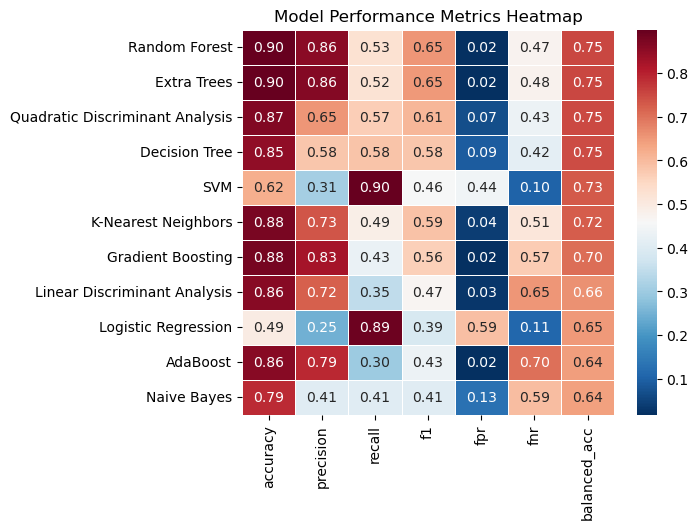

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(data, annot=True, cmap="RdBu_r", fmt=".2f", linewidths=.5)
plt.title("Model Performance Metrics Heatmap")
plt.savefig("figures/model_type_comparison_performance_heatmap.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_2781702/3304607749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=data.index, x=data["balanced_acc"], palette="RdBu_r")


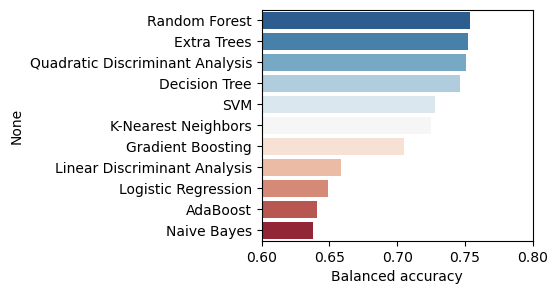

In [18]:
# Sorting by F1 Score
plt.figure(figsize=(3.5, 3))
sns.barplot(y=data.index, x=data["balanced_acc"], palette="RdBu_r")
# plt.xticks(rotation=45, ha='right')
plt.xlim(0.6, 0.8)
plt.xlabel("Balanced accuracy")
plt.savefig("figures/model_type_comparison_performance_balanced_accuracy.pdf", bbox_inches='tight')

In [14]:
data.to_csv("dt_out/model_comparison_metrics.csv")

Also try a ExtraTreesClassifier...

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

features = ["pmhc_tcr_pae", "model_2_ptm_ft4_plddt",'model_2_ptm_ft4_pae', 'model_2_ptm_ft4_plddt_0',
       'model_2_ptm_ft4_pae_0_0', 'model_2_ptm_ft4_pae_0_1',
       'model_2_ptm_ft4_pae_0_2', 'model_2_ptm_ft4_pae_0_3',
       'model_2_ptm_ft4_plddt_1', 'model_2_ptm_ft4_pae_1_0',
       'model_2_ptm_ft4_pae_1_1', 'model_2_ptm_ft4_pae_1_2',
       'model_2_ptm_ft4_pae_1_3', 'model_2_ptm_ft4_plddt_2',
       'model_2_ptm_ft4_pae_2_0', 'model_2_ptm_ft4_pae_2_1',
       'model_2_ptm_ft4_pae_2_2', 'model_2_ptm_ft4_pae_2_3',
       'model_2_ptm_ft4_plddt_3', 'model_2_ptm_ft4_pae_3_0',
       'model_2_ptm_ft4_pae_3_1', 'model_2_ptm_ft4_pae_3_2',
       'model_2_ptm_ft4_pae_3_3',]

X = df[features]
y = df["positive"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

m = ExtraTreesClassifier(n_estimators=100, random_state=1)
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_validate

m.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [8]:
X.columns

Index(['pmhc_tcr_pae', 'model_2_ptm_ft4_plddt', 'model_2_ptm_ft4_pae',
       'model_2_ptm_ft4_plddt_0', 'model_2_ptm_ft4_pae_0_0',
       'model_2_ptm_ft4_pae_0_1', 'model_2_ptm_ft4_pae_0_2',
       'model_2_ptm_ft4_pae_0_3', 'model_2_ptm_ft4_plddt_1',
       'model_2_ptm_ft4_pae_1_0', 'model_2_ptm_ft4_pae_1_1',
       'model_2_ptm_ft4_pae_1_2', 'model_2_ptm_ft4_pae_1_3',
       'model_2_ptm_ft4_plddt_2', 'model_2_ptm_ft4_pae_2_0',
       'model_2_ptm_ft4_pae_2_1', 'model_2_ptm_ft4_pae_2_2',
       'model_2_ptm_ft4_pae_2_3', 'model_2_ptm_ft4_plddt_3',
       'model_2_ptm_ft4_pae_3_0', 'model_2_ptm_ft4_pae_3_1',
       'model_2_ptm_ft4_pae_3_2', 'model_2_ptm_ft4_pae_3_3'],
      dtype='object')

In [7]:
y

0        False
1        False
2        False
3        False
4         True
         ...  
10987    False
10988    False
10989    False
10990    False
10991    False
Name: positive, Length: 10992, dtype: bool

In [183]:
y_pred = m.predict(X_test)
y_proba = m.predict_proba(X_test)[:, 1]

In [184]:
accuracy_score(y_test, y_pred)

0.8926784902228285

Now, train 100 to look at consistency.

In [186]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Optional, Dict, Any

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score


@dataclass
class ExtraTreesEnsembleResult:
    models: List[ExtraTreesClassifier]
    metrics: pd.DataFrame                 # per-run metrics
    feature_importances: pd.DataFrame     # per-run importances (rows=runs, cols=features)
    mean_auc: float
    std_auc: float
    mean_acc: float
    std_acc: float


def train_extratrees_ensemble_auc(
    df: pd.DataFrame,
    features: List[str],
    label_col: str = "positive",
    n_runs: int = 100,
    test_size: float = 0.2,
    base_seed: int = 0,
    stratify: bool = True,
    et_params: Optional[Dict[str, Any]] = None,
) -> ExtraTreesEnsembleResult:
    """
    Train an ExtraTrees ensemble over repeated train/test splits.
    Computes per-run metrics + per-run feature_importances_.

    Parameters
    ----------
    df : DataFrame
    features : list[str]
    label_col : str
    n_runs : int
    test_size : float
    base_seed : int
        Run i uses seed = base_seed + i
    stratify : bool
        Whether to stratify train/test split by y (recommended for imbalanced labels)
    et_params : dict
        ExtraTreesClassifier kwargs override
    """
    missing = [c for c in features + [label_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    X = df[features].copy()
    y = df[label_col].astype(int).copy()
    
    class_weight = {0: 1.0, 1: 10.0}
    
    default_params = dict(
        n_estimators=100,
        n_jobs=-1,
        class_weight=class_weight,
    )
    if et_params:
        default_params.update(et_params)

    models: List[ExtraTreesClassifier] = []
    rows_metrics = []
    rows_importances = []

    for i in range(n_runs):
        seed = base_seed + i
        print(f"Training run: {i} (seed={seed})")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed,
            stratify=y if stratify else None,
        )

        model = ExtraTreesClassifier(random_state=seed, **default_params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        auc_val = roc_auc_score(y_test, y_proba)

        rows_metrics.append({
            "run": i,
            "seed": seed,
            "auc": float(auc_val),
            "acc": float(acc),
            "n_test_pos": int((y_test == 1).sum()),
            "n_test_neg": int((y_test == 0).sum()),
        })

        rows_importances.append(pd.Series(model.feature_importances_, index=features, name=i))
        models.append(model)

    metrics = pd.DataFrame(rows_metrics).sort_values("run").reset_index(drop=True)
    importances = pd.DataFrame(rows_importances).sort_index()

    mean_auc = float(metrics["auc"].mean())
    std_auc = float(metrics["auc"].std(ddof=1)) if n_runs > 1 else 0.0
    mean_acc = float(metrics["acc"].mean())
    std_acc = float(metrics["acc"].std(ddof=1)) if n_runs > 1 else 0.0

    print("✅ ExtraTrees (Repeated Splits) Performance")
    print(f"Runs:      {n_runs}")
    print(f"Mean AUC:  {mean_auc:.3f} ± {std_auc:.3f}")
    print(f"Mean Acc:  {mean_acc:.3f} ± {std_acc:.3f}")

    return ExtraTreesEnsembleResult(
        models=models,
        metrics=metrics,
        feature_importances=importances,
        mean_auc=mean_auc,
        std_auc=std_auc,
        mean_acc=mean_acc,
        std_acc=std_acc,
    )

In [203]:
features=["pmhc_tcr_pae", "model_2_ptm_ft4_plddt",'model_2_ptm_ft4_pae', 'model_2_ptm_ft4_plddt_0',
       'model_2_ptm_ft4_pae_0_0', 'model_2_ptm_ft4_pae_0_1',
       'model_2_ptm_ft4_pae_0_2', 'model_2_ptm_ft4_pae_0_3',
       'model_2_ptm_ft4_plddt_1', 'model_2_ptm_ft4_pae_1_0',
       'model_2_ptm_ft4_pae_1_1', 'model_2_ptm_ft4_pae_1_2',
       'model_2_ptm_ft4_pae_1_3', 'model_2_ptm_ft4_plddt_2',
       'model_2_ptm_ft4_pae_2_0', 'model_2_ptm_ft4_pae_2_1',
       'model_2_ptm_ft4_pae_2_2', 'model_2_ptm_ft4_pae_2_3',
       'model_2_ptm_ft4_plddt_3', 'model_2_ptm_ft4_pae_3_0',
       'model_2_ptm_ft4_pae_3_1', 'model_2_ptm_ft4_pae_3_2',
       'model_2_ptm_ft4_pae_3_3',]

res_et = train_extratrees_ensemble_auc(
    df=df,
    features=features,
    label_col="positive",
    n_runs=100,
    test_size=0.2,
)

# 


Training run: 0 (seed=0)
Training run: 1 (seed=1)
Training run: 2 (seed=2)
Training run: 3 (seed=3)
Training run: 4 (seed=4)
Training run: 5 (seed=5)
Training run: 6 (seed=6)
Training run: 7 (seed=7)
Training run: 8 (seed=8)
Training run: 9 (seed=9)
Training run: 10 (seed=10)
Training run: 11 (seed=11)
Training run: 12 (seed=12)
Training run: 13 (seed=13)
Training run: 14 (seed=14)
Training run: 15 (seed=15)
Training run: 16 (seed=16)
Training run: 17 (seed=17)
Training run: 18 (seed=18)
Training run: 19 (seed=19)
Training run: 20 (seed=20)
Training run: 21 (seed=21)
Training run: 22 (seed=22)
Training run: 23 (seed=23)
Training run: 24 (seed=24)
Training run: 25 (seed=25)
Training run: 26 (seed=26)
Training run: 27 (seed=27)
Training run: 28 (seed=28)
Training run: 29 (seed=29)
Training run: 30 (seed=30)
Training run: 31 (seed=31)
Training run: 32 (seed=32)
Training run: 33 (seed=33)
Training run: 34 (seed=34)
Training run: 35 (seed=35)
Training run: 36 (seed=36)
Training run: 37 (see

In [204]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_feature_importance(
    result,
    top_n: int = None,
    figsize=(6, 4),
    savepath: str | None = None,
):
    """
    Plot mean ± SD feature importance from ExtraTrees ensemble.

    Parameters
    ----------
    result : ExtraTreesEnsembleResult
    top_n : int or None
        If provided, plot only top N features.
    figsize : tuple
    savepath : str or None
        If provided, saves figure (PDF recommended for vector output).
    """

    # mean + std across runs
    imp_mean = result.feature_importances.mean(axis=0)
    imp_std = result.feature_importances.std(axis=0, ddof=1)

    imp_df = (
        pd.DataFrame({
            "feature": imp_mean.index,
            "mean_importance": imp_mean.values,
            "std_importance": imp_std.values,
        })
        .sort_values("mean_importance", ascending=False)
    )

    if top_n is not None:
        imp_df = imp_df.head(top_n)

    plt.figure(figsize=figsize)

    plt.barh(
        imp_df["feature"][::-1],
        imp_df["mean_importance"][::-1],
        xerr=imp_df["std_importance"][::-1],
        capsize=3,
    )

    plt.xlabel("Feature importance (mean ± SD)")
    plt.ylabel("")
    plt.title("ExtraTrees feature importance")

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, format="pdf")  # vector-safe
    plt.show()

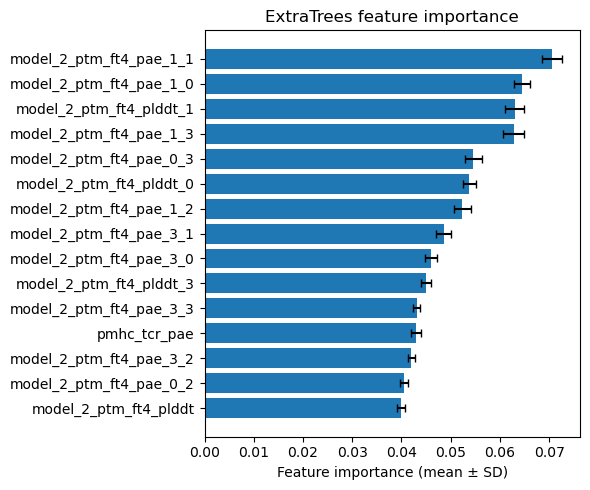

In [205]:
plot_feature_importance(
    result=res_et,
    top_n=15,
    figsize=(6, 5),
#     savepath="extratrees_feature_importance.pdf",
)

In [190]:
from pathlib import Path
import joblib, json
from typing import List, Dict, Any, Optional, Tuple

def save_extratrees_ensemble(result: ExtraTreesEnsembleResult, features: List[str], out_prefix: str, et_params: Optional[dict]=None):
    out_prefix = Path(out_prefix)
    out_prefix.parent.mkdir(parents=True, exist_ok=True)

    # models
    joblib.dump(result.models, out_prefix.with_suffix(".models.joblib"))

    # meta
    meta = {
        "model_type": "extratrees",
        "n_models": len(result.models),
        "features": list(features),
        "params": et_params or {},
    }
    out_prefix.with_suffix(".meta.json").write_text(json.dumps(meta, indent=2))

    # metrics + importances + shap summary
    result.metrics.to_csv(out_prefix.with_suffix(".metrics.csv"), index=False)
    result.feature_importances.to_csv(out_prefix.with_suffix(".importances.csv"), index=True)
#     result.shap_summary.to_csv(out_prefix.with_suffix(".shap_summary.csv"), index=True)

    print("✅ Saved ExtraTrees ensemble to:")
    print(" ", out_prefix.with_suffix(".models.joblib"))
    print(" ", out_prefix.with_suffix(".meta.json"))
    print(" ", out_prefix.with_suffix(".metrics.csv"))
    print(" ", out_prefix.with_suffix(".importances.csv"))
#     print(" ", out_prefix.with_suffix(".shap_summary.csv"))


def load_extratrees_ensemble(out_prefix: str):
    out_prefix = Path(out_prefix)
    models = joblib.load(out_prefix.with_suffix(".models.joblib"))
    meta = json.loads(out_prefix.with_suffix(".meta.json").read_text())
    metrics = pd.read_csv(out_prefix.with_suffix(".metrics.csv"))
    importances = pd.read_csv(out_prefix.with_suffix(".importances.csv"), index_col=0)
#     shap_summary = pd.read_csv(out_prefix.with_suffix(".shap_summary.csv"), index_col=0)
    return models, meta, metrics, importances
def predict_with_extratrees_ensemble(
    models: List[ExtraTreesClassifier],
    df_new: pd.DataFrame,
    features: List[str],
    proba_agg: str = "mean",
    threshold: float = 0.5,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
      p: aggregated probability (n_samples,)
      yhat: thresholded prediction (n_samples,)
      probas: per-model probabilities (n_models, n_samples)
    """
    X_new = df_new[features].copy()

    probas = np.vstack([m.predict_proba(X_new)[:, 1] for m in models])

    if proba_agg == "mean":
        p = probas.mean(axis=0)
    elif proba_agg == "median":
        p = np.median(probas, axis=0)
    else:
        raise ValueError("proba_agg must be 'mean' or 'median'")

    yhat = (p >= threshold).astype(int)
    return p, yhat, probas

In [191]:
save_extratrees_ensemble(res_et, features=features, out_prefix="dt_out/ET_ensemble_allFeatures")


✅ Saved ExtraTrees ensemble to:
  dt_out/ET_ensemble_allFeatures.models.joblib
  dt_out/ET_ensemble_allFeatures.meta.json
  dt_out/ET_ensemble_allFeatures.metrics.csv
  dt_out/ET_ensemble_allFeatures.importances.csv


In [192]:
models, meta, metrics, importances = load_extratrees_ensemble("dt_out/ET_ensemble_allFeatures")
df_new = df
p, yhat, probas = predict_with_extratrees_ensemble(models, df_new=df_new, features=features)
df_new["prediction"] = p
df_new["prediction_yhat"] = yhat

In [193]:
df_new[["positive","prediction_yhat"]].value_counts()

positive  prediction_yhat
False     0                  8997
True      1                  1972
False     1                    23
Name: count, dtype: int64

In [ ]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# SHAP can be heavy; install with: pip install shap
import shap


@dataclass
class ExtraTreesEnsembleResult:
    models: List[ExtraTreesClassifier]
    metrics: pd.DataFrame                 # per-run metrics
    feature_importances: pd.DataFrame     # per-run importances (rows=runs, cols=features)
    shap_summary: pd.DataFrame            # global SHAP importance (mean(|shap|)) per feature, averaged across runs
    mean_auc: float
    std_auc: float
    mean_acc: float
    std_acc: float


def train_extratrees_ensemble_auc(
    df: pd.DataFrame,
    features: List[str],
    label_col: str = "positive",
    n_runs: int = 100,
    test_size: float = 0.2,
    shap_max_samples: int = 2000,
    shap_background: int = 200,
) -> ExtraTreesEnsembleResult:
    """
    Train an ExtraTrees ensemble over repeated train/test splits.
    Also computes per-run feature importance + SHAP global importance.

    Notes on SHAP:
    - Uses TreeExplainer (fast-ish), but can still be heavy.
    - Computes SHAP on up to `shap_max_samples` test samples per run.
    - Uses up to `shap_background` samples as background.
    """

    missing = [c for c in features + [label_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    X = df[features].copy()
    y = df[label_col].copy()

    models: List[ExtraTreesClassifier] = []
    rows_metrics = []
    rows_importances = []

    # accumulate SHAP global importances per run (mean abs shap per feature)
    shap_global_runs = []
    base_seed = 0
    
    for i in range(n_runs):
        print("Training run: " + str(i))
        seed = base_seed + i

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed,
#             stratify=y
        )

        model = ExtraTreesClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        auc_val = roc_auc_score(y_test, y_proba)

        rows_metrics.append({
            "run": i,
            "seed": seed,
            "auc": auc_val,
            "acc": acc,
            "n_test_pos": int((y_test == 1).sum()),
            "n_test_neg": int((y_test == 0).sum()),
        })

        rows_importances.append(pd.Series(model.feature_importances_, index=features, name=i))
        models.append(model)

        # ---- SHAP (global) ----
        # sample test set for SHAP to keep runtime manageable
        if shap_max_samples is not None and len(X_test) > shap_max_samples:
            X_shap = X_test.sample(shap_max_samples, random_state=seed)
        else:
            X_shap = X_test

        # background sample from training set
        if shap_background is not None and len(X_train) > shap_background:
            X_bg = X_train.sample(shap_background, random_state=seed)
        else:
            X_bg = X_train

        explainer = shap.TreeExplainer(model, data=X_bg, feature_perturbation="interventional")

        shap_vals = explainer.shap_values(X_shap, check_additivity=False)

        # For binary classification, shap returns either:
        # - list of 2 arrays (n_samples, n_features) or
        # - a single array (n_samples, n_features) depending on version
        if isinstance(shap_vals, list) and len(shap_vals) == 2:
            shap_pos = shap_vals[1]  # class 1
        else:
            shap_pos = shap_vals
            if shap_pos.ndim == 3:
                # (n_samples, n_features, n_classes) -> take class 1
                shap_pos = shap_pos[:, :, 1]

        shap_global = np.mean(np.abs(shap_pos), axis=0)  # (n_features,)
        shap_global_runs.append(pd.Series(shap_global, index=features, name=i))

    metrics = pd.DataFrame(rows_metrics).sort_values("run").reset_index(drop=True)
    importances = pd.DataFrame(rows_importances).sort_index()

    mean_auc = float(metrics["auc"].mean())
    std_auc = float(metrics["auc"].std(ddof=1)) if n_runs > 1 else 0.0
    mean_acc = float(metrics["acc"].mean())
    std_acc = float(metrics["acc"].std(ddof=1)) if n_runs > 1 else 0.0

    shap_df = pd.DataFrame(shap_global_runs).sort_index()
    shap_summary = pd.DataFrame({
        "mean_abs_shap": shap_df.mean(axis=0),
        "std_abs_shap": shap_df.std(axis=0, ddof=1) if n_runs > 1 else 0.0,
    }).sort_values("mean_abs_shap", ascending=False)

    print("✅ ExtraTrees (Repeated Splits) Performance")
    print(f"Runs:      {n_runs}")
    print(f"Mean AUC:  {mean_auc:.3f} ± {std_auc:.3f}")
    print(f"Mean Acc:  {mean_acc:.3f} ± {std_acc:.3f}")

    return ExtraTreesEnsembleResult(
        models=models,
        metrics=metrics,
        feature_importances=importances,
        shap_summary=shap_summary,
        mean_auc=mean_auc,
        std_auc=std_auc,
        mean_acc=mean_acc,
        std_acc=std_acc,
    )
